In [1]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import os, re, random, joblib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from IPython.display import FileLink, display

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, cohen_kappa_score, f1_score)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset, DatasetDict

In [2]:
# ============================================================
# CELL 2 — Config  (only edit these)
# ============================================================
DATA_CSV         = "/kaggle/input/datasets/feryaljadallah/refinedbayyin/Refined_Bayyin_Dataset.csv"
LABEL_COL        = "Readability_Level"
NUMERIC_COLS     = ["Word_Count", "Word", "Lex", "D3Lex"]
CATEGORICAL_COLS = ["Document", "Source", "Book", "Author",
                    "Domain", "Text_Class", "Dataset_Source"]

CAMELBERT_MODEL  = "CAMeL-Lab/bert-base-arabic-camelbert-msa"
MAX_LEN          = 128
BATCH_SIZE       = 64
EPOCHS           = 10
NUM_CLASSES      = 6
LSTM_HIDDEN      = 256
DROPOUT          = 0.4
WEIGHT_DECAY     = 1e-2
UNFREEZE_LAST_N  = 6
BERT_LR          = 2e-5
HEAD_LR          = 5e-4
ORDINAL_LAMBDA   = 0.4
PATIENCE         = 3
SEED             = 42
DEVICE           = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")

Device: cuda


In [3]:
# ============================================================
# CELL 3 — Helpers
# ============================================================
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

def normalize_arabic(text):
    if not isinstance(text, str): return ""
    text = text.replace("أ","ا").replace("إ","ا").replace("آ","ا").replace("ى","ي")
    text = re.sub("[ًٌٍَُِّْـ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

set_seed(SEED)

In [4]:
# ============================================================
# CELL 4 — Data loading, split & preprocessing
#           (runs ONCE — shared by both training variants)
# ============================================================
print("Loading dataset via HuggingFace (matches transformer split)...")
dataset    = load_dataset("csv", data_files={"train": DATA_CSV}, split="train")
train_test = dataset.train_test_split(test_size=0.3, seed=SEED)
test_valid = train_test["test"].train_test_split(test_size=1/3, seed=SEED)

splits = DatasetDict({
    "train":      train_test["train"],
    "test":       test_valid["train"],
    "validation": test_valid["test"],
})
print(f"Train: {len(splits['train'])} | Test: {len(splits['test'])} | Val: {len(splits['validation'])}")

train_df = splits["train"].to_pandas()
val_df   = splits["validation"].to_pandas()
test_df  = splits["test"].to_pandas()

# Normalize both text columns upfront
for df_ in [train_df, val_df, test_df]:
    df_["Sentence"] = df_["Sentence"].astype(str).apply(normalize_arabic)
    df_["D3Tok"]    = df_["D3Tok"].astype(str).apply(normalize_arabic)

# Labels → 0-indexed
for df_ in [train_df, val_df, test_df]:
    if df_[LABEL_COL].min() == 1:
        df_[LABEL_COL] = df_[LABEL_COL] - 1

# Numeric metadata — fit on train only
for col in NUMERIC_COLS:
    for df_ in [train_df, val_df, test_df]:
        df_[col] = pd.to_numeric(df_[col], errors="coerce").fillna(0.0)

meta_scaler = StandardScaler()
train_df[NUMERIC_COLS] = meta_scaler.fit_transform(train_df[NUMERIC_COLS])
val_df[NUMERIC_COLS]   = meta_scaler.transform(val_df[NUMERIC_COLS])
test_df[NUMERIC_COLS]  = meta_scaler.transform(test_df[NUMERIC_COLS])

# Categorical features — fit on train only
label_encoders = {}
for c in CATEGORICAL_COLS:
    for df_ in [train_df, val_df, test_df]:
        df_[c] = df_[c].fillna("UNKNOWN").astype(str)
    le = LabelEncoder()
    le.fit(train_df[c])
    label_encoders[c] = le
    known = set(le.classes_)
    for df_ in [train_df, val_df, test_df]:
        df_[c] = df_[c].apply(lambda x: x if x in known else le.classes_[0])
        df_[c] = le.transform(df_[c])

print("✓ Preprocessing complete")

Loading dataset via HuggingFace (matches transformer split)...


Generating train split: 0 examples [00:00, ? examples/s]

Train: 31441 | Test: 8984 | Val: 4492
✓ Preprocessing complete


In [5]:
# ============================================================
# CELL 5 — Dataset class
# ============================================================
class TransformerDataset(Dataset):
    """text_col can be 'Sentence' or 'D3Tok' — passed at construction time."""
    def __init__(self, df, tokenizer, text_col):
        self.texts       = df[text_col].values
        self.labels      = df[LABEL_COL].astype(int).values
        self.numeric     = df[NUMERIC_COLS].values.astype(np.float32)
        self.categorical = df[CATEGORICAL_COLS].values.astype(np.int64)
        self.tokenizer   = tokenizer

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]), padding="max_length", truncation=True,
            max_length=MAX_LEN, return_tensors="pt"
        )
        return {
            "input_ids":     enc["input_ids"].squeeze(0),
            "attention_mask":enc["attention_mask"].squeeze(0),
            "numeric":       torch.tensor(self.numeric[idx],    dtype=torch.float32),
            "categorical":   torch.tensor(self.categorical[idx],dtype=torch.long),
            "label":         torch.tensor(self.labels[idx],     dtype=torch.long),
        }

In [7]:
# ============================================================
# CELL 6 — Model definition
# ============================================================
def freeze_bert_except_last_n(bert_model, n=6):
    for param in bert_model.parameters():
        param.requires_grad = False
    num_layers = len(bert_model.encoder.layer)
    for i in range(max(0, num_layers - n), num_layers):
        for param in bert_model.encoder.layer[i].parameters():
            param.requires_grad = True
    if hasattr(bert_model, "pooler") and bert_model.pooler is not None:
        for param in bert_model.pooler.parameters():
            param.requires_grad = True


class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out, mask=None):
        scores = self.attn(lstm_out).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        return (lstm_out * weights).sum(dim=1)


class BiLSTMWithMeta(nn.Module):
    def __init__(self, categorical_cardinalities, num_numeric,
                 lstm_hidden=256, lstm_layers=2, meta_proj_dim=128,
                 num_classes=6, dropout=0.3,
                 bert_model_name=None, unfreeze_last_n=6):
        super().__init__()
        self.bert      = AutoModel.from_pretrained(bert_model_name)
        freeze_bert_except_last_n(self.bert, n=unfreeze_last_n)
        input_dim      = self.bert.config.hidden_size

        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=lstm_hidden,
            num_layers=lstm_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )
        self.attn_pool = AttentionPooling(lstm_hidden * 2)

        self.cat_names      = list(categorical_cardinalities.keys())
        self.cat_embeddings = nn.ModuleDict()
        total_cat_emb_dim   = 0
        for name, card in categorical_cardinalities.items():
            emb_dim = min(50, max(4, int(card ** 0.5)))
            self.cat_embeddings[name] = nn.Embedding(card, emb_dim)
            total_cat_emb_dim += emb_dim


        self.meta_proj = nn.Sequential(
            nn.Linear(total_cat_emb_dim + num_numeric, meta_proj_dim),
            nn.ReLU(), nn.Dropout(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2 + meta_proj_dim, 128),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, numeric_meta, categorical_meta, attention_mask=None):
        x           = self.bert(input_ids=input_ids,
                                attention_mask=attention_mask).last_hidden_state
        lstm_out, _ = self.lstm(x)
        pooled      = self.attn_pool(lstm_out, mask=attention_mask)

        cat_embs    = [self.cat_embeddings[n](categorical_meta[:, i])
                       for i, n in enumerate(self.cat_names)]
        meta_vec    = self.meta_proj(
            torch.cat([numeric_meta, torch.cat(cat_embs, dim=1)], dim=1)
        )
        return self.classifier(self.dropout(torch.cat([pooled, meta_vec], dim=1)))



In [8]:
# ============================================================
# CELL 7 — Loss & train/eval loops
# ============================================================
class OrdinalAwareLoss(nn.Module):
    def __init__(self, num_classes=6, ordinal_lambda=0.4, sigma=2.0):
        super().__init__()
        self.ordinal_lambda = ordinal_lambda
        self.sigma          = sigma
        self.num_classes    = num_classes

    def forward(self, logits, labels):
        probs      = torch.softmax(logits, dim=-1)
        true_probs = probs.gather(1, labels.unsqueeze(1)).squeeze(1)
        diff_w     = ((1.0 - true_probs.detach()) + 0.5)
        diff_w     = diff_w / diff_w.mean()

        indices  = torch.arange(self.num_classes, dtype=torch.float32,
                                device=logits.device)
        dist     = torch.abs(indices - labels.float().unsqueeze(1))
        soft_tgt = torch.exp(-dist / self.sigma)
        soft_tgt = soft_tgt / soft_tgt.sum(dim=1, keepdim=True)

        ce  = F.cross_entropy(logits, labels, reduction="none")
        kl  = F.kl_div(F.log_softmax(logits, dim=-1), soft_tgt,
                       reduction="none").sum(dim=1)
        return (ce * diff_w + self.ordinal_lambda * kl).mean()

def _to_cpu(sd):
    return {k: v.cpu() if hasattr(v, "cpu") else v for k, v in sd.items()}


def run_epoch(model, loader, optimizer=None, scheduler=None):
    training  = optimizer is not None
    model.train() if training else model.eval()
    criterion = OrdinalAwareLoss(NUM_CLASSES, ORDINAL_LAMBDA)
    total_loss, all_preds, all_trues, all_probs = 0.0, [], [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            logits = model(
                batch["input_ids"].to(DEVICE),
                batch["numeric"].to(DEVICE),
                batch["categorical"].to(DEVICE),
                batch["attention_mask"].to(DEVICE)
            )
            labels = batch["label"].to(DEVICE)
            loss   = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item() * labels.size(0)
            all_preds  += logits.detach().cpu().argmax(1).tolist()
            all_trues  += labels.cpu().tolist()
            all_probs  += torch.softmax(logits.detach().cpu(), dim=-1).tolist()

    n = len(loader.dataset)
    return total_loss / n, accuracy_score(all_trues, all_preds), all_trues, all_preds, all_probs




In [9]:
# ============================================================
# CELL 8 — Main training function (used for both variants)
# ============================================================
def train_bilstm_variant(text_col, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"\n{'#'*60}")
    print(f"# CamelBERT-BiLSTM  |  text_col = '{text_col}'")
    print(f"{'#'*60}")

    tokenizer    = AutoTokenizer.from_pretrained(CAMELBERT_MODEL, use_fast=True)
    cat_card     = {c: int(train_df[c].max()) + 1 for c in CATEGORICAL_COLS}

    train_loader = DataLoader(TransformerDataset(train_df, tokenizer, text_col),
                              batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(TransformerDataset(val_df,   tokenizer, text_col),
                              batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(TransformerDataset(test_df,  tokenizer, text_col),
                              batch_size=BATCH_SIZE, shuffle=False)

    model = BiLSTMWithMeta(
        categorical_cardinalities=cat_card,
        num_numeric=len(NUMERIC_COLS),
        lstm_hidden=LSTM_HIDDEN, meta_proj_dim=128,
        num_classes=NUM_CLASSES, dropout=DROPOUT,
        bert_model_name=CAMELBERT_MODEL,
        unfreeze_last_n=UNFREEZE_LAST_N
    ).to(DEVICE)

    no_decay             = ["bias", "LayerNorm.weight"]
    bert_params_decay    = [p for n, p in model.bert.named_parameters()
                            if p.requires_grad and not any(nd in n for nd in no_decay)]
    bert_params_no_decay = [p for n, p in model.bert.named_parameters()
                            if p.requires_grad and any(nd in n for nd in no_decay)]
    head_params          = [p for n, p in model.named_parameters()
                            if not n.startswith("bert.")]

    optimizer   = AdamW([
        {"params": bert_params_decay,    "weight_decay": WEIGHT_DECAY, "lr": BERT_LR},
        {"params": bert_params_no_decay, "weight_decay": 0.0,          "lr": BERT_LR},
        {"params": head_params,          "weight_decay": WEIGHT_DECAY, "lr": HEAD_LR},
    ], eps=1e-8)
    total_steps = len(train_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(0.10 * total_steps)),
        num_training_steps=total_steps
    )

    best_val_acc   = 0.0
    patience_ctr   = 0
    best_ckpt_path = os.path.join(output_dir, "best_bilstm_camelbert.joblib")
    start_time     = time.time()

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc, *_ = run_epoch(model, train_loader, optimizer, scheduler)
        vl_loss, vl_acc, *_ = run_epoch(model, val_loader)

        print(f"Epoch {epoch:02d} | "
              f"Train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"Val loss {vl_loss:.4f} acc {vl_acc:.4f} | "
              f"{(time.time()-start_time)/60:.1f} min")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            joblib.dump({
                "model_state": _to_cpu(model.state_dict()),
                "val_acc":     vl_acc,
                "epoch":       epoch,
                "cat_card":    cat_card,
                "text_col":    text_col,
                "config": {
                    "lstm_hidden":     LSTM_HIDDEN,
                    "dropout":         DROPOUT,
                    "num_classes":     NUM_CLASSES,
                    "bert_model_name": CAMELBERT_MODEL,
                    "unfreeze_last_n": UNFREEZE_LAST_N,
                }
            }, best_ckpt_path)
            print(f"  ✓ Best saved (val_acc={vl_acc:.4f})")
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"  ⏹ Early stopping at epoch {epoch}")
                break

    # ── Evaluate best checkpoint on test set ──
    print(f"\nEvaluating best checkpoint (epoch {joblib.load(best_ckpt_path)['epoch']})...")
    ckpt = joblib.load(best_ckpt_path)
    model.load_state_dict(ckpt["model_state"])

    _, test_acc, y_true, y_pred, _ = run_epoch(model, test_loader)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    wf1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{'='*55}")
    print(f"  Results — text_col='{text_col}'")
    print(f"{'='*55}")
    print(f"  Accuracy:    {test_acc:.4f}")
    print(f"  Weighted F1: {wf1:.4f}")
    print(f"  QWK:         {qwk:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=[f'Level {i+1}' for i in range(6)])}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=[str(i+1) for i in range(6)],
                yticklabels=[str(i+1) for i in range(6)])
    plt.title(f"Normalized Confusion Matrix — BiLSTM ({text_col})")
    plt.ylabel("True label"); plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"cm_bilstm_{text_col}.png"), dpi=150)
    plt.show()


    # Save encoders & raw test set alongside model
    joblib.dump({"meta_scaler": meta_scaler, "label_encoders": label_encoders},
                os.path.join(output_dir, "meta_encoders.joblib"))
    splits["test"].to_pandas().to_csv(
        os.path.join(output_dir, "test_set.csv"), index=False
    )

    print(f"\n✓ Files saved to {output_dir}/")
    print(f"  best_bilstm_camelbert.joblib")
    print(f"  meta_encoders.joblib")
    print(f"  test_set.csv")
    print(f"  cm_bilstm_{text_col}.png")

    del model; torch.cuda.empty_cache()

    return {"accuracy": test_acc, "f1": wf1, "qwk": qwk,
            "ckpt_path": best_ckpt_path, "output_dir": output_dir}




############################################################
# CamelBERT-BiLSTM  |  text_col = 'Sentence'
############################################################


config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-msa
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Epoch 01 | Train loss 1.4040 acc 0.5221 | Val loss 1.1468 acc 0.6906 | 4.8 min
  ✓ Best saved (val_acc=0.6906)
Epoch 02 | Train loss 1.0664 acc 0.7535 | Val loss 0.9666 acc 0.7936 | 9.7 min
  ✓ Best saved (val_acc=0.7936)
Epoch 03 | Train loss 0.9451 acc 0.8130 | Val loss 0.9274 acc 0.8110 | 14.5 min
  ✓ Best saved (val_acc=0.8110)
Epoch 04 | Train loss 0.8698 acc 0.8507 | Val loss 0.9385 acc 0.8146 | 19.4 min
  ✓ Best saved (val_acc=0.8146)
Epoch 05 | Train loss 0.7998 acc 0.8820 | Val loss 0.9596 acc 0.8134 | 24.3 min
Epoch 06 | Train loss 0.7324 acc 0.9075 | Val loss 1.0228 acc 0.8110 | 29.1 min
Epoch 07 | Train loss 0.6757 acc 0.9307 | Val loss 1.0568 acc 0.8077 | 34.0 min
  ⏹ Early stopping at epoch 7

Evaluating best checkpoint (epoch 4)...

  Results — text_col='Sentence'
  Accuracy:    0.8096
  Weighted F1: 0.8095
  QWK:         0.8849

              precision    recall  f1-score   support

     Level 1       0.69      0.85      0.77      1519
     Level 2       0.75      0.69 

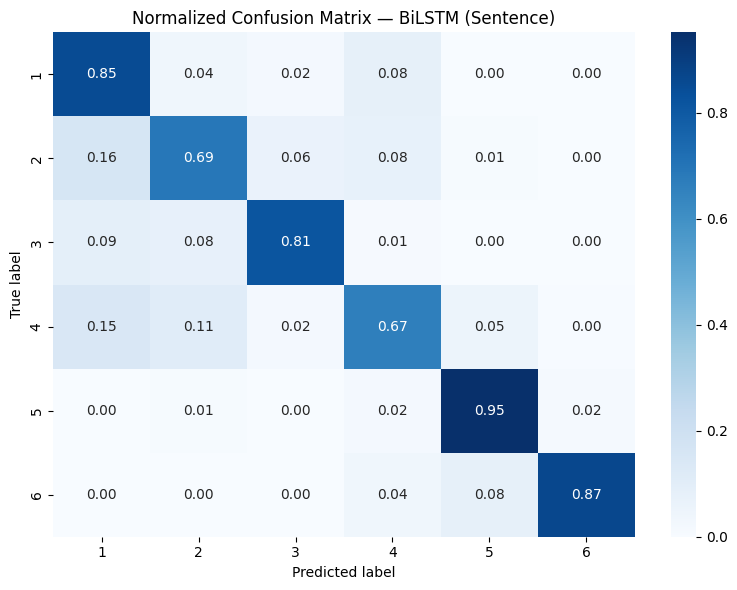


✓ Files saved to /kaggle/working/bilstm_sentence/
  best_bilstm_camelbert.joblib
  meta_encoders.joblib
  test_set.csv
  cm_bilstm_Sentence.png


In [10]:
# ============================================================
# CELL 9 — Run Variant 1: Sentence
# ============================================================
results_sentence = train_bilstm_variant(
    text_col   = "Sentence",
    output_dir = "/kaggle/working/bilstm_sentence"
)



############################################################
# CamelBERT-BiLSTM  |  text_col = 'D3Tok'
############################################################


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-msa
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train loss 1.3961 acc 0.5242 | Val loss 1.1323 acc 0.6879 | 4.9 min
  ✓ Best saved (val_acc=0.6879)
Epoch 02 | Train loss 1.0720 acc 0.7466 | Val loss 0.9424 acc 0.8023 | 9.7 min
  ✓ Best saved (val_acc=0.8023)
Epoch 03 | Train loss 0.9526 acc 0.8111 | Val loss 0.9119 acc 0.8172 | 14.6 min
  ✓ Best saved (val_acc=0.8172)
Epoch 04 | Train loss 0.8772 acc 0.8451 | Val loss 0.9172 acc 0.8146 | 19.5 min
Epoch 05 | Train loss 0.8125 acc 0.8723 | Val loss 0.9527 acc 0.8166 | 24.3 min
Epoch 06 | Train loss 0.7541 acc 0.8998 | Val loss 0.9861 acc 0.8134 | 29.2 min
  ⏹ Early stopping at epoch 6

Evaluating best checkpoint (epoch 3)...

  Results — text_col='D3Tok'
  Accuracy:    0.8063
  Weighted F1: 0.8056
  QWK:         0.8793

              precision    recall  f1-score   support

     Level 1       0.67      0.86      0.75      1519
     Level 2       0.76      0.67      0.71      1528
     Level 3       0.87      0.83      0.85      1353
     Level 4       0.72      0.63      0.

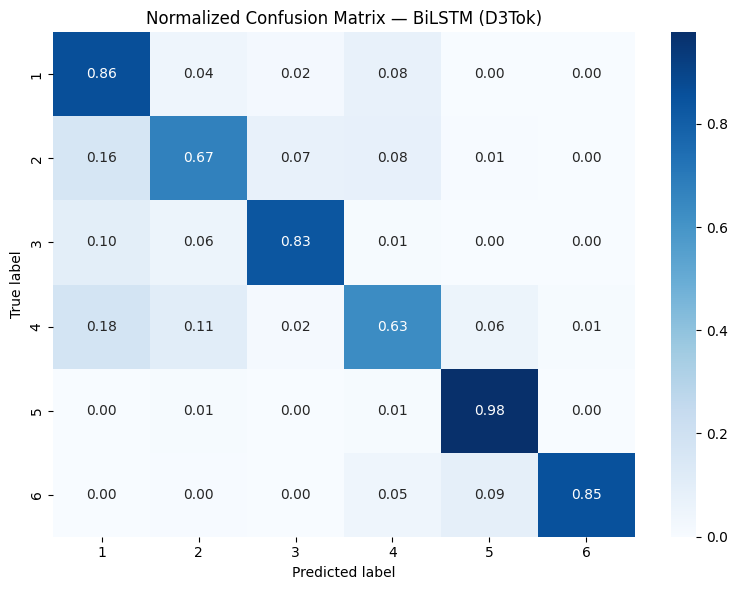


✓ Files saved to /kaggle/working/bilstm_d3tok/
  best_bilstm_camelbert.joblib
  meta_encoders.joblib
  test_set.csv
  cm_bilstm_D3Tok.png


In [11]:
# ============================================================
# CELL 10 — Run Variant 2: D3Tok
# ============================================================
results_d3tok = train_bilstm_variant(
    text_col   = "D3Tok",
    output_dir = "/kaggle/working/bilstm_d3tok"
)

In [12]:
# ============================================================
# CELL 11 — Final comparison
# ============================================================
print(f"\n{'='*55}")
print("FINAL COMPARISON — Both BiLSTM Variants")
print(f"{'='*55}")
print(f"  {'Variant':<12} | {'Accuracy':>8} | {'F1':>8} | {'QWK':>8}")
print(f"  {'-'*44}")
print(f"  {'Sentence':<12} | {results_sentence['accuracy']:>8.4f} | "
      f"{results_sentence['f1']:>8.4f} | {results_sentence['qwk']:>8.4f}")
print(f"  {'D3Tok':<12} | {results_d3tok['accuracy']:>8.4f} | "
      f"{results_d3tok['f1']:>8.4f} | {results_d3tok['qwk']:>8.4f}")

best = "Sentence" if results_sentence["qwk"] >= results_d3tok["qwk"] else "D3Tok"
print(f"\n  Best variant by QWK: {best}")


FINAL COMPARISON — Both BiLSTM Variants
  Variant      | Accuracy |       F1 |      QWK
  --------------------------------------------
  Sentence     |   0.8096 |   0.8095 |   0.8849
  D3Tok        |   0.8063 |   0.8056 |   0.8793

  Best variant by QWK: Sentence


In [17]:
# ============================================================
# CELL 12 — Download both as zips
# ============================================================
import os
os.chdir("/kaggle/working")  

shutil.make_archive("BiLSTM_Sentence", "zip", "/kaggle/working/bilstm_sentence")
shutil.make_archive("BiLSTM_D3Tok",    "zip", "/kaggle/working/bilstm_d3tok")

print("Click to download:")
display(FileLink("BiLSTM_Sentence.zip"))  # ← relative path, no /kaggle/working/
display(FileLink("BiLSTM_D3Tok.zip"))

Click to download:


/kaggle/working/BiLSTM_Sentence.zip

/kaggle/working/BiLSTM_D3Tok.zip

In [18]:
import joblib
from sklearn.metrics import classification_report

for variant, output_dir in [("Sentence", "/kaggle/working/bilstm_sentence"),
                              ("D3Tok",    "/kaggle/working/bilstm_d3tok")]:
    ckpt      = joblib.load(f"{output_dir}/best_bilstm_camelbert.joblib")
    text_col  = ckpt["text_col"]
    cat_card  = ckpt["cat_card"]
    cfg       = ckpt["config"]

    model = BiLSTMWithMeta(
        categorical_cardinalities=cat_card,
        num_numeric=len(NUMERIC_COLS),
        lstm_hidden=cfg["lstm_hidden"], meta_proj_dim=128,
        num_classes=cfg["num_classes"], dropout=cfg["dropout"],
        bert_model_name=cfg["bert_model_name"],
        unfreeze_last_n=cfg["unfreeze_last_n"]
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])

    tokenizer   = AutoTokenizer.from_pretrained(cfg["bert_model_name"], use_fast=True)
    test_loader = DataLoader(
        TransformerDataset(test_df, tokenizer, text_col),
        batch_size=BATCH_SIZE, shuffle=False
    )

    _, _, y_true, y_pred, _ = run_epoch(model, test_loader)

    print(f"\n{'='*55}")
    print(f"  CamelBERT-BiLSTM — text_col='{text_col}'")
    print(f"{'='*55}")
    print(classification_report(
        y_true, y_pred,
        target_names=[f"Level {i+1}" for i in range(6)],
        digits=4
    ))

    del model; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-msa
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  CamelBERT-BiLSTM — text_col='Sentence'
              precision    recall  f1-score   support

     Level 1     0.6930    0.8545    0.7653      1519
     Level 2     0.7521    0.6911    0.7203      1528
     Level 3     0.8691    0.8145    0.8409      1353
     Level 4     0.7270    0.6653    0.6948      1437
     Level 5     0.8620    0.9516    0.9046      1530
     Level 6     0.9791    0.8689    0.9207      1617

    accuracy                         0.8096      8984
   macro avg     0.8137    0.8076    0.8078      8984
weighted avg     0.8153    0.8096    0.8095      8984



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-msa
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  CamelBERT-BiLSTM — text_col='D3Tok'
              precision    recall  f1-score   support

     Level 1     0.6703    0.8591    0.7530      1519
     Level 2     0.7604    0.6728    0.7139      1528
     Level 3     0.8664    0.8337    0.8497      1353
     Level 4     0.7227    0.6312    0.6738      1437
     Level 5     0.8642    0.9771    0.9172      1530
     Level 6     0.9878    0.8541    0.9161      1617

    accuracy                         0.8063      8984
   macro avg     0.8119    0.8047    0.8040      8984
weighted avg     0.8137    0.8063    0.8056      8984



In [23]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_fscore_support
import shutil
from IPython.display import FileLink, display

In [24]:
results = {}
LEVEL_NAMES = [f"Level {i+1}" for i in range(6)]
for vname, (res_dict, df_processed, test_raw) in {
    "Sentence": (results_sentence, test_df, pd.read_csv("/kaggle/working/bilstm_sentence/test_set.csv")),
    "D3Tok":    (results_d3tok,    test_df, pd.read_csv("/kaggle/working/bilstm_d3tok/test_set.csv")),
}.items():
    pass  

In [25]:
# ============================================================
# BRIDGE — Build analysis dicts from training results
# ============================================================
import pandas as pd
import numpy as np
from sklearn.calibration import calibration_curve

OUT_DIR = "/kaggle/working/error_analysis_both"
os.makedirs(OUT_DIR, exist_ok=True)

def build_analysis_dict(train_result, test_raw_csv):
    """Convert train_bilstm_variant output into analysis-ready dict."""
    # Reload checkpoint to get predictions
    ckpt      = joblib.load(train_result["ckpt_path"])
    text_col  = ckpt["text_col"]
    cfg       = ckpt["config"]
    cat_card  = ckpt["cat_card"]

    model = BiLSTMWithMeta(
        categorical_cardinalities=cat_card,
        num_numeric=len(NUMERIC_COLS),
        lstm_hidden=cfg["lstm_hidden"], meta_proj_dim=128,
        num_classes=cfg["num_classes"], dropout=cfg["dropout"],
        bert_model_name=cfg["bert_model_name"],
        unfreeze_last_n=cfg["unfreeze_last_n"]
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    tokenizer   = AutoTokenizer.from_pretrained(cfg["bert_model_name"], use_fast=True)
    test_loader = DataLoader(
        TransformerDataset(test_df, tokenizer, text_col),
        batch_size=BATCH_SIZE, shuffle=False
    )

    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            logits = model(batch["input_ids"].to(DEVICE), batch["numeric"].to(DEVICE),
                           batch["categorical"].to(DEVICE), batch["attention_mask"].to(DEVICE))
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            all_probs  += probs.tolist()
            all_preds  += logits.cpu().argmax(1).tolist()
            all_labels += batch["label"].tolist()

    del model; torch.cuda.empty_cache()

    all_probs  = np.array(all_probs)
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Build dataframe with raw readable values for metadata
    test_raw = pd.read_csv(test_raw_csv)
    df = test_raw.copy()
    df["true_label"] = all_labels
    df["pred_label"] = all_preds
    df["confidence"] = all_probs.max(axis=1)
    df["correct"]    = (all_labels == all_preds)
    df["error_dist"] = np.abs(all_labels - all_preds)
    for i in range(NUM_CLASSES):
        df[f"prob_class_{i}"] = all_probs[:, i]

    return {
        "df":     df,
        "probs":  all_probs,
        "preds":  all_preds,
        "labels": all_labels,
        "acc":    train_result["accuracy"],
        "qwk":    train_result["qwk"],
        "f1":     train_result["f1"],
        "text_col": text_col,
    }

results = {
    "Sentence": build_analysis_dict(
        results_sentence, "/kaggle/working/bilstm_sentence/test_set.csv"),
    "D3Tok":    build_analysis_dict(
        results_d3tok,    "/kaggle/working/bilstm_d3tok/test_set.csv"),
}
print("✓ Analysis dicts ready")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-msa
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-msa
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Analysis dicts ready


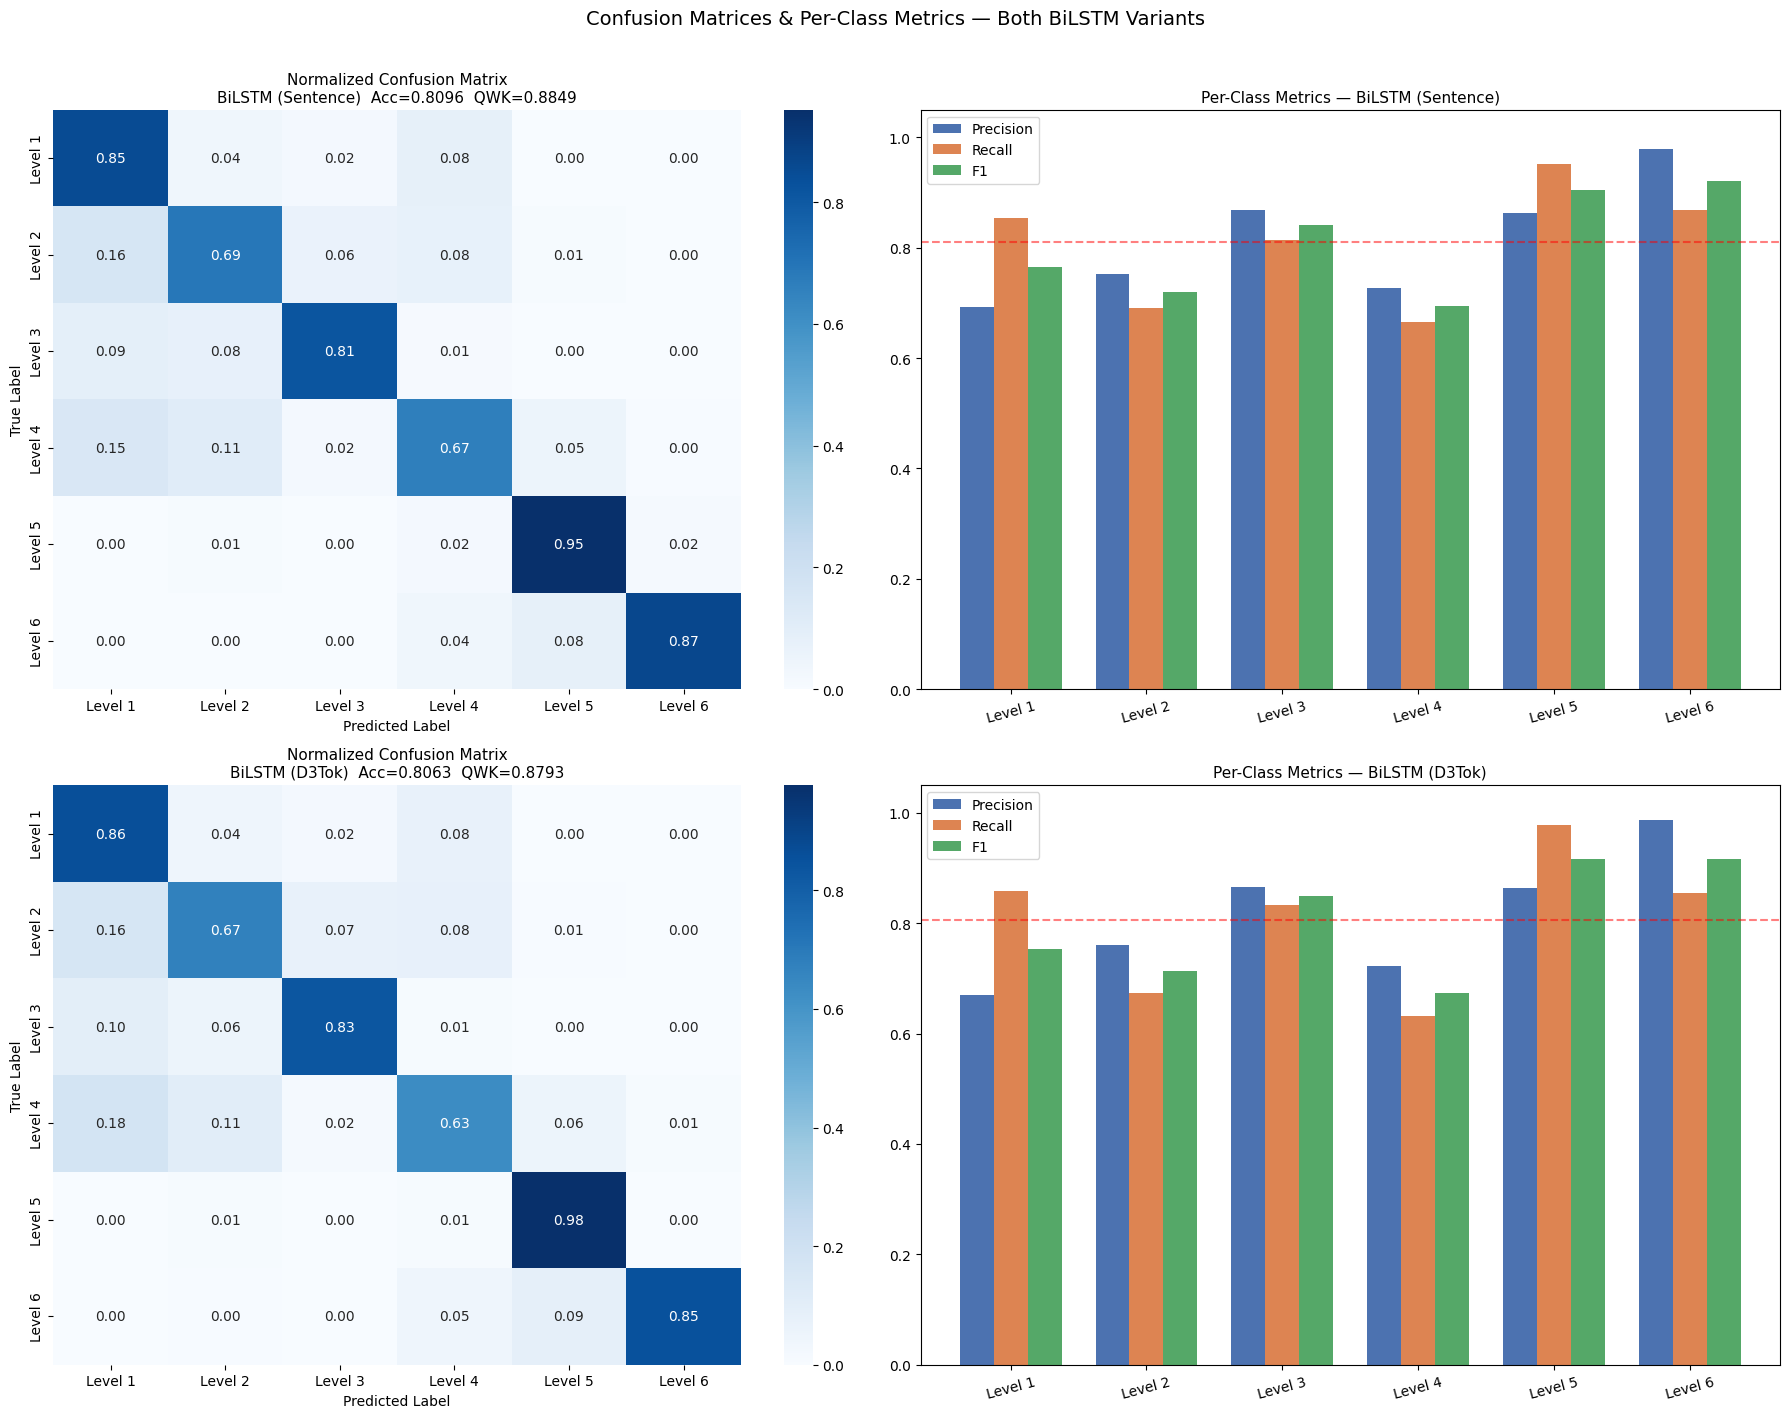


── Classification Report: BiLSTM (Sentence) ──
              precision    recall  f1-score   support

     Level 1     0.6930    0.8545    0.7653      1519
     Level 2     0.7521    0.6911    0.7203      1528
     Level 3     0.8691    0.8145    0.8409      1353
     Level 4     0.7270    0.6653    0.6948      1437
     Level 5     0.8620    0.9516    0.9046      1530
     Level 6     0.9791    0.8689    0.9207      1617

    accuracy                         0.8096      8984
   macro avg     0.8137    0.8076    0.8078      8984
weighted avg     0.8153    0.8096    0.8095      8984


── Classification Report: BiLSTM (D3Tok) ──
              precision    recall  f1-score   support

     Level 1     0.6703    0.8591    0.7530      1519
     Level 2     0.7604    0.6728    0.7139      1528
     Level 3     0.8664    0.8337    0.8497      1353
     Level 4     0.7227    0.6312    0.6738      1437
     Level 5     0.8642    0.9771    0.9172      1530
     Level 6     0.9878    0.8541    0.

In [26]:
# ============================================================
# Analysis 1: Confusion Matrix + Per-class Metrics
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for row_idx, (vname, res) in enumerate(results.items()):
    labels, preds = res["labels"], res["preds"]

    # Confusion matrix
    cm = confusion_matrix(labels, preds, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                ax=axes[row_idx][0],
                xticklabels=LEVEL_NAMES, yticklabels=LEVEL_NAMES)
    axes[row_idx][0].set_title(
        f"Normalized Confusion Matrix\nBiLSTM ({vname})  Acc={res['acc']:.4f}  QWK={res['qwk']:.4f}",
        fontsize=11)
    axes[row_idx][0].set_ylabel("True Label")
    axes[row_idx][0].set_xlabel("Predicted Label")

    # Per-class metrics
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average=None, labels=list(range(NUM_CLASSES)))
    x = np.arange(NUM_CLASSES)
    w = 0.25
    axes[row_idx][1].bar(x - w, prec, w, label="Precision", color="#4C72B0")
    axes[row_idx][1].bar(x,     rec,  w, label="Recall",    color="#DD8452")
    axes[row_idx][1].bar(x + w, f1,   w, label="F1",        color="#55A868")
    axes[row_idx][1].set_xticks(x)
    axes[row_idx][1].set_xticklabels(LEVEL_NAMES, rotation=15)
    axes[row_idx][1].set_ylim(0, 1.05)
    axes[row_idx][1].set_title(f"Per-Class Metrics — BiLSTM ({vname})", fontsize=11)
    axes[row_idx][1].legend()
    axes[row_idx][1].axhline(res["acc"], color="red", linestyle="--",
                              alpha=0.5, label=f"Overall Acc")

plt.suptitle("Confusion Matrices & Per-Class Metrics — Both BiLSTM Variants",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_confusion_perclass_both.png", dpi=150, bbox_inches="tight")
plt.show()

for vname, res in results.items():
    print(f"\n── Classification Report: BiLSTM ({vname}) ──")
    print(classification_report(res["labels"], res["preds"],
                                target_names=LEVEL_NAMES, digits=4))




BiLSTM (Sentence) — Ordinal errors:
  Adjacent (dist=1):     48.4%
  Non-adjacent (dist>1): 51.6%
  Over-predicted:        33.8%
  Under-predicted:       66.2%

BiLSTM (D3Tok) — Ordinal errors:
  Adjacent (dist=1):     45.3%
  Non-adjacent (dist>1): 54.7%
  Over-predicted:        32.9%
  Under-predicted:       67.1%


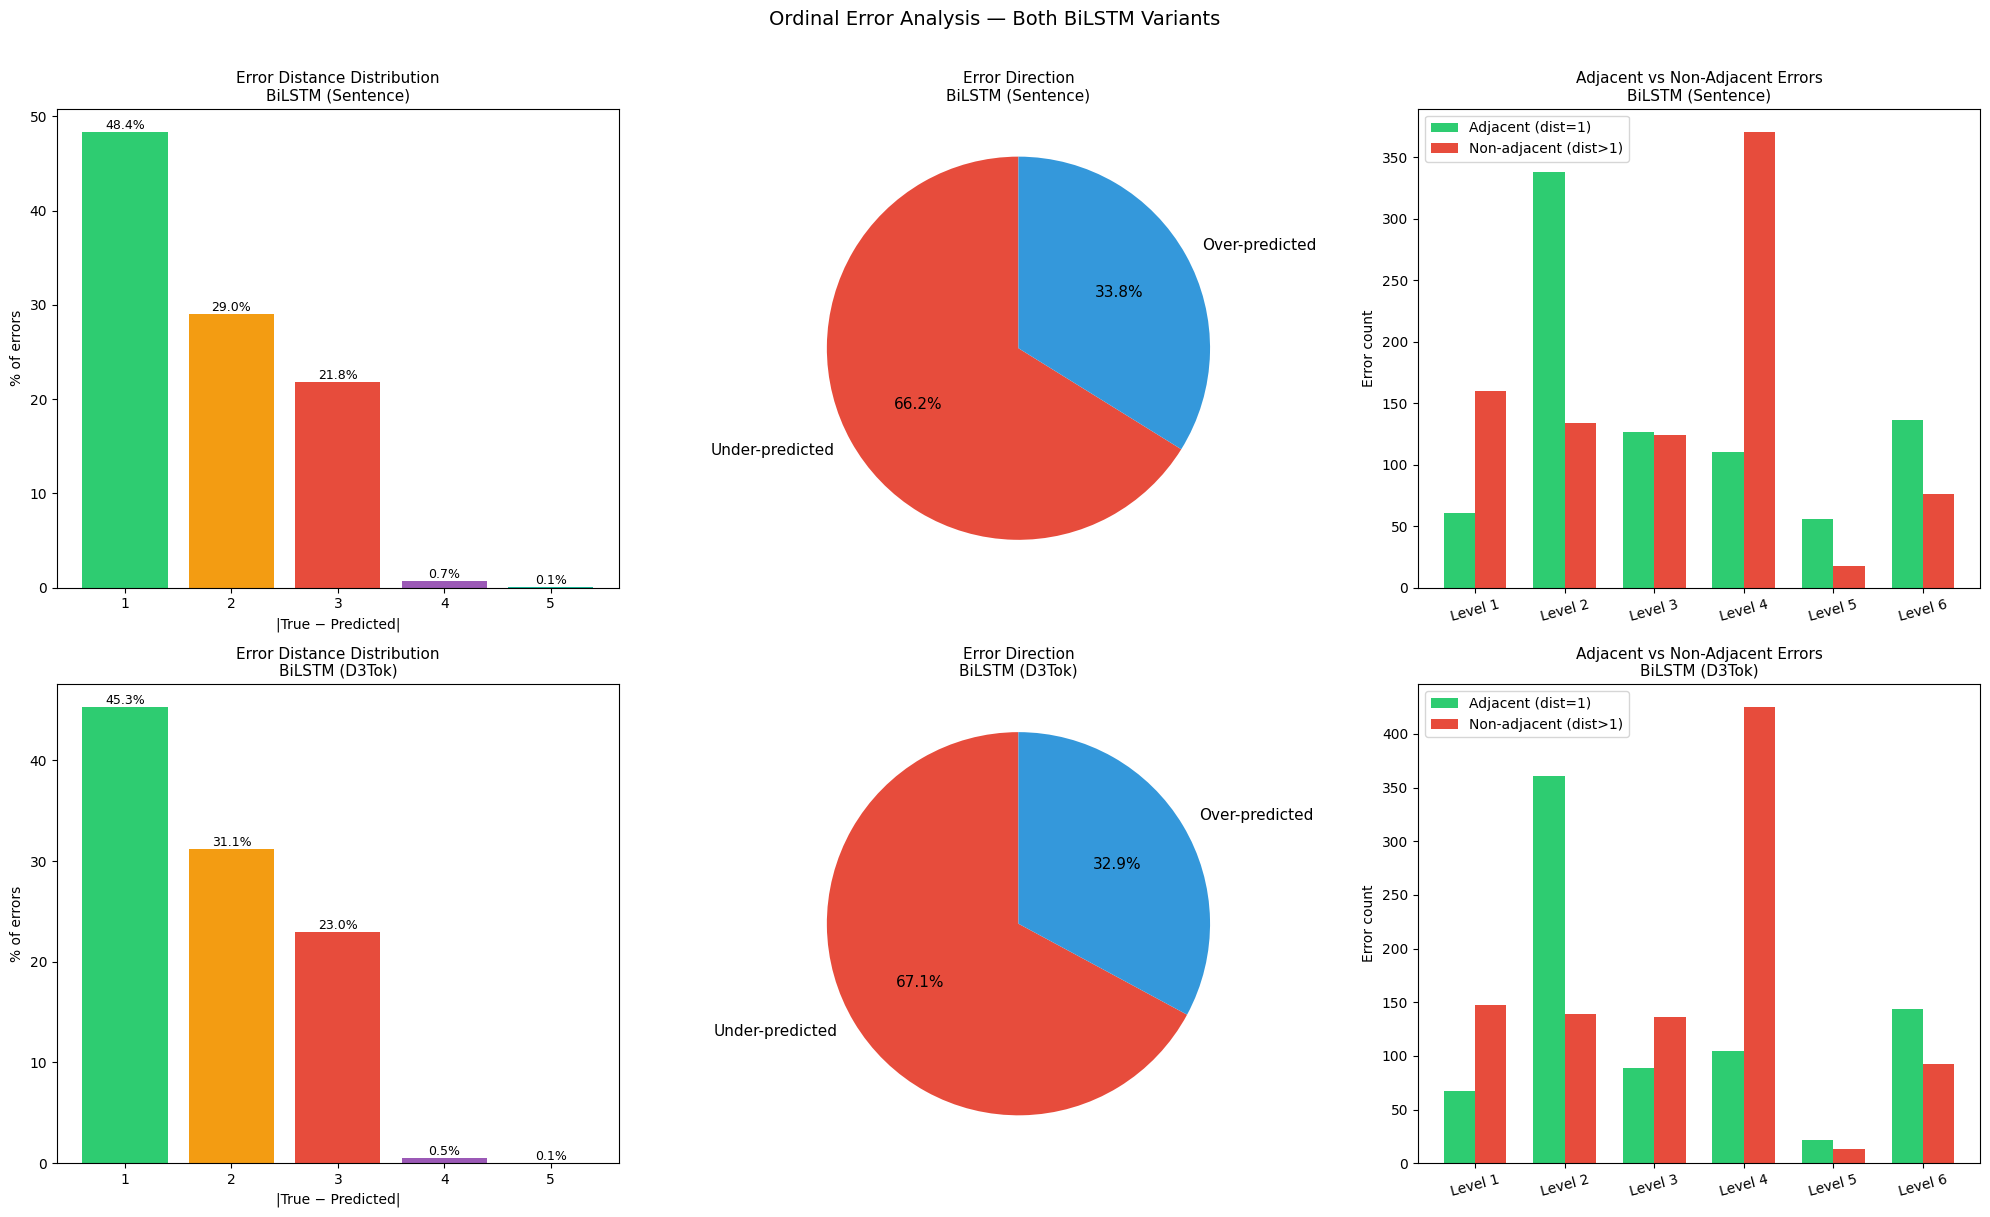

In [27]:
# ============================================================
# Analysis 2: Ordinal Error Analysis
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for row_idx, (vname, res) in enumerate(results.items()):
    df         = res["df"]
    errors_df  = df[~df["correct"]].copy()
    total_err  = len(errors_df)

    # 2a — Error distance distribution
    dist_counts = errors_df["error_dist"].value_counts().sort_index()
    colors_bar  = ["#2ecc71","#f39c12","#e74c3c","#9b59b6","#1abc9c"]
    axes[row_idx][0].bar(dist_counts.index,
                          dist_counts.values / total_err * 100,
                          color=colors_bar[:len(dist_counts)])
    axes[row_idx][0].set_xlabel("|True − Predicted|")
    axes[row_idx][0].set_ylabel("% of errors")
    axes[row_idx][0].set_title(f"Error Distance Distribution\nBiLSTM ({vname})", fontsize=11)
    for d, v in zip(dist_counts.index, dist_counts.values):
        axes[row_idx][0].text(d, v/total_err*100 + 0.3,
                               f"{v/total_err*100:.1f}%", ha="center", fontsize=9)

    # 2b — Over vs Under prediction
    errors_df["direction"] = errors_df.apply(
        lambda r: "Over-predicted" if r["pred_label"] > r["true_label"]
        else "Under-predicted", axis=1)
    dir_counts = errors_df["direction"].value_counts()
    axes[row_idx][1].pie(dir_counts.values, labels=dir_counts.index,
                          autopct="%1.1f%%", colors=["#e74c3c","#3498db"],
                          startangle=90, textprops={"fontsize": 11})
    axes[row_idx][1].set_title(f"Error Direction\nBiLSTM ({vname})", fontsize=11)

    # 2c — Adjacent vs non-adjacent per class
    adjacent     = errors_df[errors_df["error_dist"] == 1].groupby("true_label").size()
    non_adjacent = errors_df[errors_df["error_dist"] >  1].groupby("true_label").size()
    x = np.arange(NUM_CLASSES)
    w = 0.35
    axes[row_idx][2].bar(x - w/2, [adjacent.get(i, 0)     for i in range(NUM_CLASSES)],
                          w, label="Adjacent (dist=1)",     color="#2ecc71")
    axes[row_idx][2].bar(x + w/2, [non_adjacent.get(i, 0) for i in range(NUM_CLASSES)],
                          w, label="Non-adjacent (dist>1)", color="#e74c3c")
    axes[row_idx][2].set_xticks(x)
    axes[row_idx][2].set_xticklabels(LEVEL_NAMES, rotation=15)
    axes[row_idx][2].set_title(f"Adjacent vs Non-Adjacent Errors\nBiLSTM ({vname})", fontsize=11)
    axes[row_idx][2].set_ylabel("Error count")
    axes[row_idx][2].legend()

    adj_pct = (errors_df["error_dist"] == 1).mean() * 100
    print(f"\nBiLSTM ({vname}) — Ordinal errors:")
    print(f"  Adjacent (dist=1):     {adj_pct:.1f}%")
    print(f"  Non-adjacent (dist>1): {100-adj_pct:.1f}%")
    print(f"  Over-predicted:        {dir_counts.get('Over-predicted',  0)/total_err*100:.1f}%")
    print(f"  Under-predicted:       {dir_counts.get('Under-predicted', 0)/total_err*100:.1f}%")

plt.suptitle("Ordinal Error Analysis — Both BiLSTM Variants", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_ordinal_errors_both.png", dpi=150, bbox_inches="tight")
plt.show()




BiLSTM (Sentence) — Calibration:
  Mean conf correct:   0.7065
  Mean conf incorrect: 0.5730
  Confidence gap:      0.1334

BiLSTM (D3Tok) — Calibration:
  Mean conf correct:   0.6835
  Mean conf incorrect: 0.5294
  Confidence gap:      0.1541


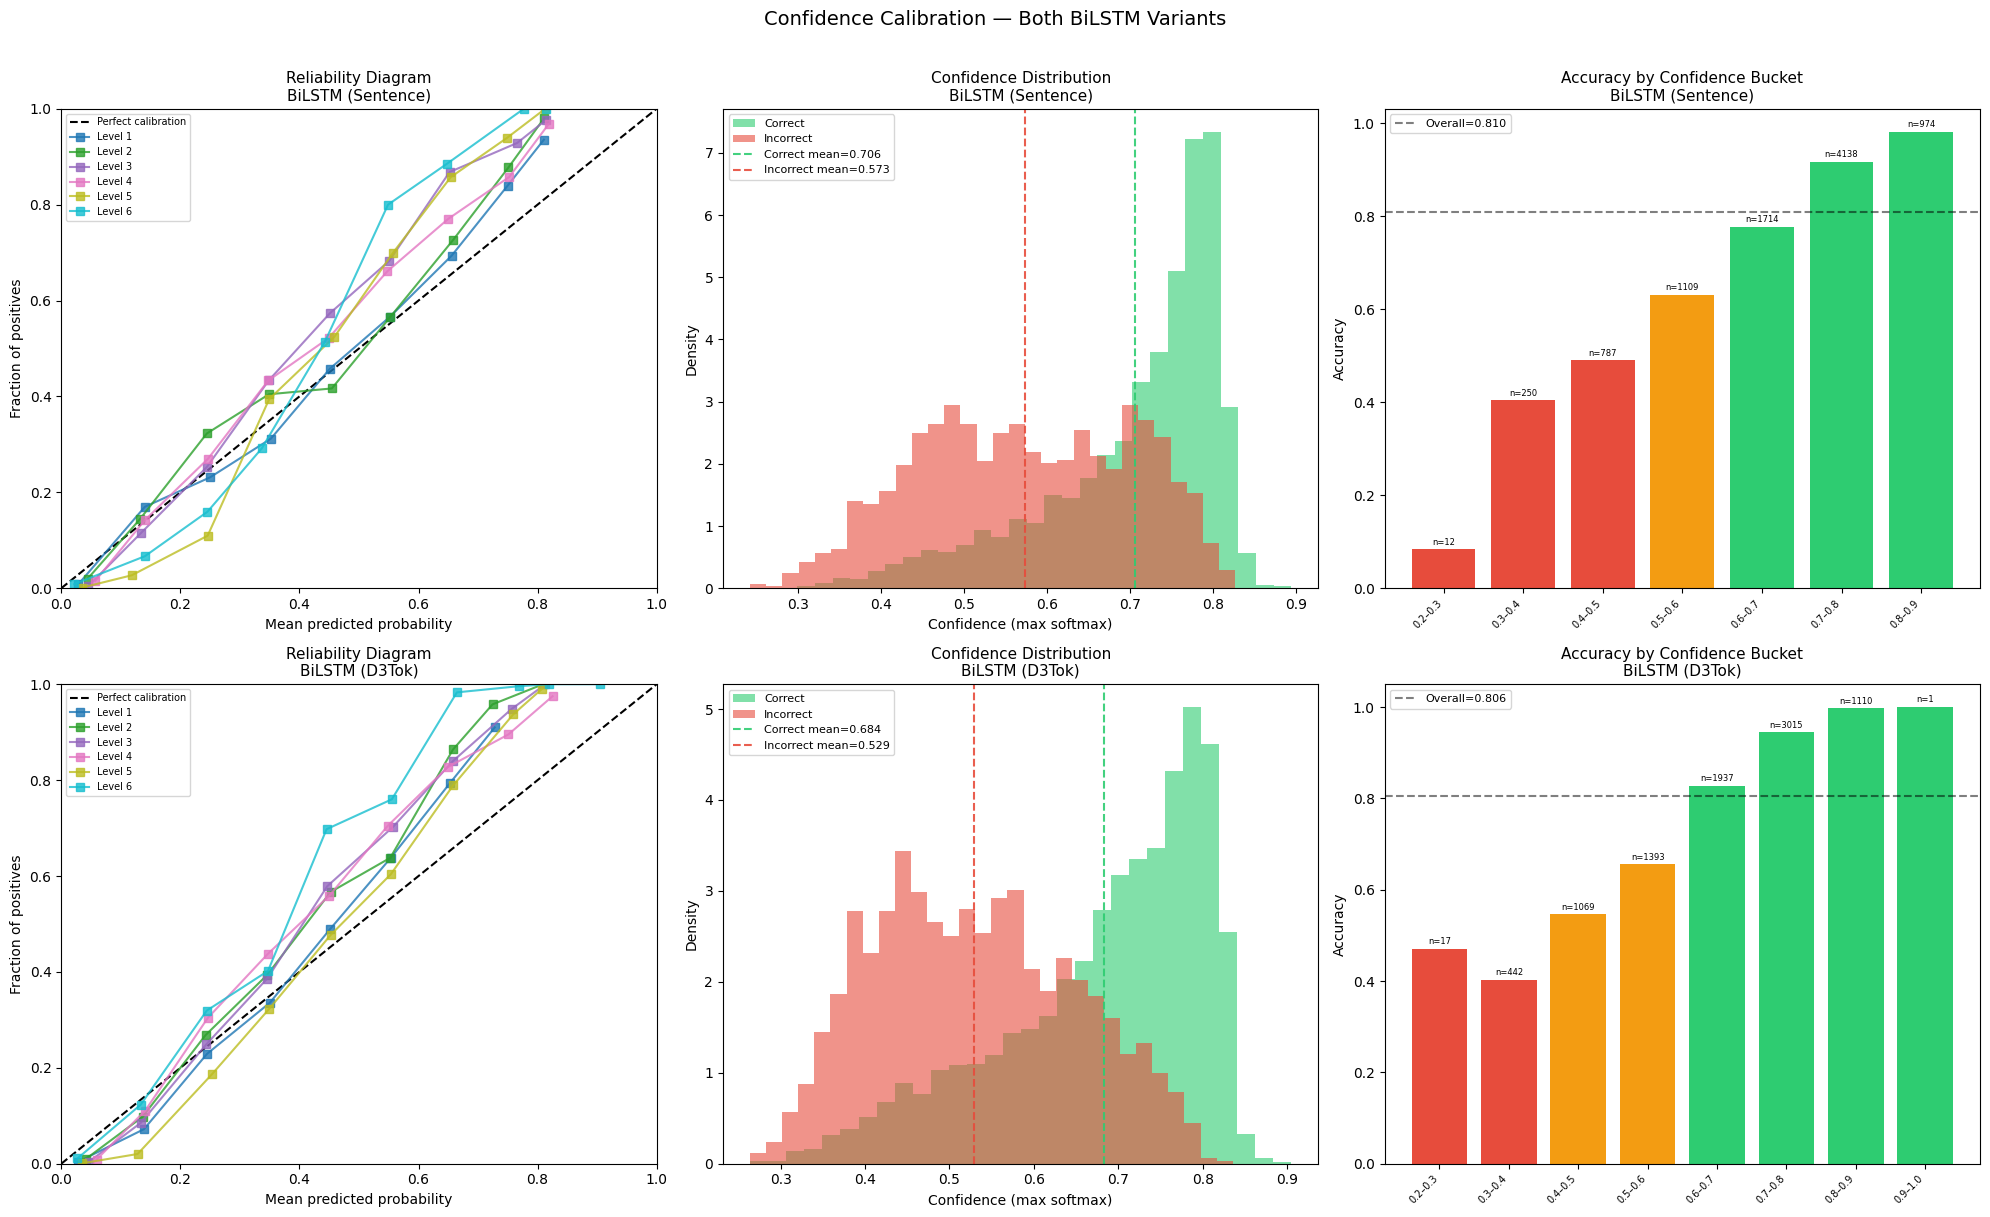

In [28]:
# ============================================================
# Analysis 3: Confidence Calibration
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for row_idx, (vname, res) in enumerate(results.items()):
    df     = res["df"]
    labels = res["labels"]
    probs  = res["probs"]
    acc    = res["acc"]

    # 3a — Reliability diagram
    axes[row_idx][0].plot([0,1],[0,1], "k--", label="Perfect calibration")
    colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
    for cls in range(NUM_CLASSES):
        try:
            fop, mpv = calibration_curve(
                (labels == cls).astype(int), probs[:, cls], n_bins=10)
            axes[row_idx][0].plot(mpv, fop, "s-", color=colors[cls],
                                   label=LEVEL_NAMES[cls], alpha=0.8)
        except Exception:
            pass
    axes[row_idx][0].set_xlabel("Mean predicted probability")
    axes[row_idx][0].set_ylabel("Fraction of positives")
    axes[row_idx][0].set_title(f"Reliability Diagram\nBiLSTM ({vname})", fontsize=11)
    axes[row_idx][0].legend(fontsize=7)
    axes[row_idx][0].set_xlim(0, 1); axes[row_idx][0].set_ylim(0, 1)

    # 3b — Confidence distribution: correct vs incorrect
    axes[row_idx][1].hist(df[df["correct"]]["confidence"],
                           bins=30, alpha=0.6, color="#2ecc71",
                           label="Correct", density=True)
    axes[row_idx][1].hist(df[~df["correct"]]["confidence"],
                           bins=30, alpha=0.6, color="#e74c3c",
                           label="Incorrect", density=True)
    mc = df[df["correct"]]["confidence"].mean()
    mi = df[~df["correct"]]["confidence"].mean()
    axes[row_idx][1].axvline(mc, color="#2ecc71", linestyle="--", alpha=0.9,
                              label=f"Correct mean={mc:.3f}")
    axes[row_idx][1].axvline(mi, color="#e74c3c", linestyle="--", alpha=0.9,
                              label=f"Incorrect mean={mi:.3f}")
    axes[row_idx][1].set_xlabel("Confidence (max softmax)")
    axes[row_idx][1].set_ylabel("Density")
    axes[row_idx][1].set_title(f"Confidence Distribution\nBiLSTM ({vname})", fontsize=11)
    axes[row_idx][1].legend(fontsize=8)

    # 3c — Accuracy by confidence bucket
    bins      = np.linspace(0, 1, 11)
    bin_lbls  = [f"{b:.1f}–{b+0.1:.1f}" for b in bins[:-1]]
    df2       = df.copy()
    df2["conf_bin"] = pd.cut(df2["confidence"], bins=bins, labels=bin_lbls)
    conf_acc  = df2.groupby("conf_bin", observed=True)["correct"].agg(["mean","count"])
    bar_clrs  = ["#e74c3c" if v < 0.5 else "#f39c12" if v < 0.75 else "#2ecc71"
                 for v in conf_acc["mean"]]
    axes[row_idx][2].bar(range(len(conf_acc)), conf_acc["mean"], color=bar_clrs)
    axes[row_idx][2].set_xticks(range(len(conf_acc)))
    axes[row_idx][2].set_xticklabels(conf_acc.index, rotation=45, ha="right", fontsize=7)
    axes[row_idx][2].set_ylabel("Accuracy")
    axes[row_idx][2].set_title(f"Accuracy by Confidence Bucket\nBiLSTM ({vname})", fontsize=11)
    axes[row_idx][2].axhline(acc, color="black", linestyle="--",
                              alpha=0.5, label=f"Overall={acc:.3f}")
    axes[row_idx][2].legend(fontsize=8)
    for i, (av, cnt) in enumerate(zip(conf_acc["mean"], conf_acc["count"])):
        axes[row_idx][2].text(i, av + 0.01, f"n={cnt}", ha="center", fontsize=6)

    print(f"\nBiLSTM ({vname}) — Calibration:")
    print(f"  Mean conf correct:   {mc:.4f}")
    print(f"  Mean conf incorrect: {mi:.4f}")
    print(f"  Confidence gap:      {mc - mi:.4f}")

plt.suptitle("Confidence Calibration — Both BiLSTM Variants", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_calibration_both.png", dpi=150, bbox_inches="tight")
plt.show()

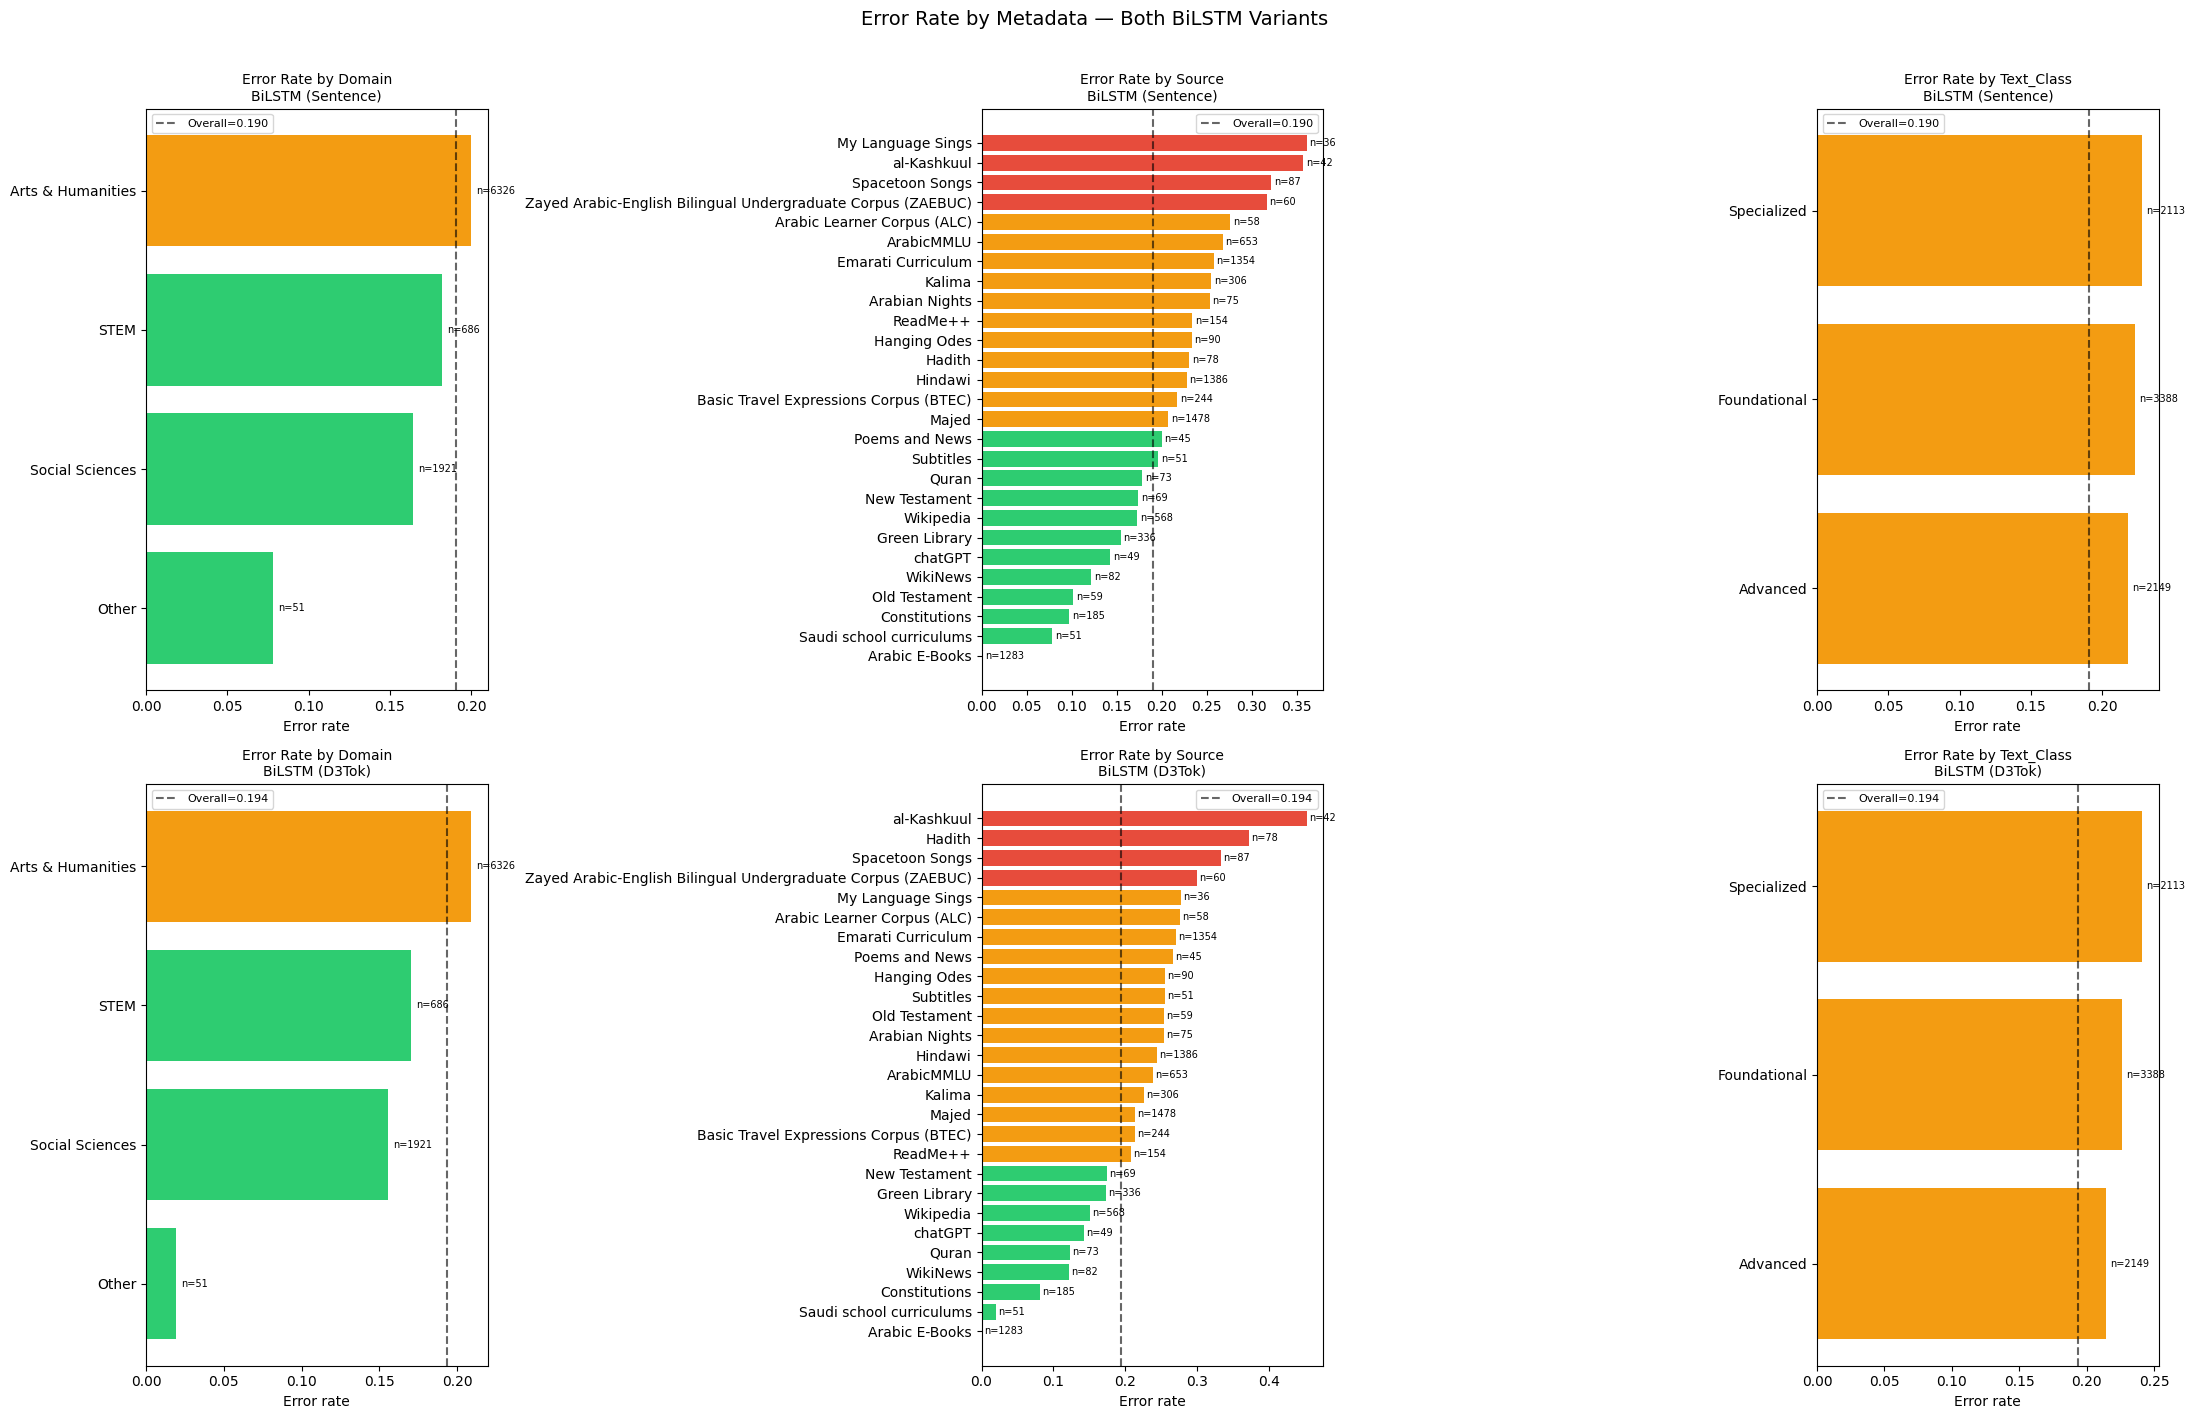


BiLSTM (Sentence) — Top problematic categories (min 15 samples):
  Domain:
    Arts & Humanities              error=0.200  n=6326
    STEM                           error=0.182  n=686
    Social Sciences                error=0.164  n=1921
  Source:
    My Language Sings              error=0.361  n=36
    al-Kashkuul                    error=0.357  n=42
    Spacetoon Songs                error=0.322  n=87
  Text_Class:
    Specialized                    error=0.228  n=2113
    Foundational                   error=0.223  n=3388
    Advanced                       error=0.218  n=2149

BiLSTM (D3Tok) — Top problematic categories (min 15 samples):
  Domain:
    Arts & Humanities              error=0.209  n=6326
    STEM                           error=0.171  n=686
    Social Sciences                error=0.156  n=1921
  Source:
    al-Kashkuul                    error=0.452  n=42
    Hadith                         error=0.372  n=78
    Spacetoon Songs                error=0.333  n=87
  Text

In [29]:
# ============================================================
# Analysis 4: Error distribution by metadata
# ============================================================
meta_cols = ["Domain", "Source", "Text_Class"]
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

for row_idx, (vname, res) in enumerate(results.items()):
    df  = res["df"]
    acc = res["acc"]

    for col_idx, col in enumerate(meta_cols):
        ax  = axes[row_idx][col_idx]
        grp = (df.groupby(col)["correct"]
               .agg(["mean","count"])
               .reset_index())
        grp["error_rate"] = 1 - grp["mean"]
        grp = grp[grp["count"] >= 15].sort_values("error_rate", ascending=True)

        bar_clrs = ["#e74c3c" if v > 0.3 else "#f39c12" if v > 0.2 else "#2ecc71"
                    for v in grp["error_rate"]]
        bars = ax.barh(grp[col].astype(str), grp["error_rate"], color=bar_clrs)
        ax.axvline(1 - acc, color="black", linestyle="--",
                   alpha=0.6, label=f"Overall={1-acc:.3f}")
        ax.set_xlabel("Error rate")
        ax.set_title(f"Error Rate by {col}\nBiLSTM ({vname})", fontsize=10)
        ax.legend(fontsize=8)
        for bar, cnt in zip(bars, grp["count"]):
            ax.text(bar.get_width() + 0.003,
                    bar.get_y() + bar.get_height() / 2,
                    f"n={cnt}", va="center", fontsize=7)


plt.suptitle("Error Rate by Metadata — Both BiLSTM Variants", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_metadata_errors_both.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top problematic categories
for vname, res in results.items():
    df = res["df"]
    print(f"\nBiLSTM ({vname}) — Top problematic categories (min 15 samples):")
    for col in meta_cols:
        grp = (df.groupby(col)["correct"]
               .agg(["mean","count"]))
        grp["error_rate"] = 1 - grp["mean"]
        grp = grp[grp["count"] >= 15].sort_values("error_rate", ascending=False).head(3)
        print(f"  {col}:")
        for cat, row in grp.iterrows():
            print(f"    {str(cat):<30} error={row['error_rate']:.3f}  n={int(row['count'])}")




TOP 20 HARD ERRORS — BiLSTM (Sentence)
#     True  Pred   Conf  Dist  Domain              Text
--------------------------------------------------------------------------------
1    L6→L4    0.827     2   Social Sciences     لم تكن الطبيعة البشرية في اصل فطرتها كما هي عليه ا…
2    L2→L1    0.825     1   Arts & Humanities   ثالثا اختار الاجابة الصحيحة
3    L2→L3    0.820     1   Arts & Humanities   لا يجوز للمسلم ان ينفق وقته فيما يضره او فيما لا ي…
4    L2→L3    0.820     1   Arts & Humanities   وبما انه مصروفك الخاص فانت حرة في انفاقه كما تريدي…
5    L2→L3    0.819     1   Arts & Humanities   لكن الضابط الكبير لم يكن يحب اللعب او الكلام
6    L6→L4    0.819     2   Social Sciences     لكن لا شك انه كان شكلا مختلفا تماما للعولمة
7    L2→L1    0.815     1   Arts & Humanities   كيف يتواصل الناس مع بعضهم بعضا اليوم
8    L4→L2    0.810     2   Arts & Humanities   لن اقابل هولاء السفراء
9    L3→L1    0.809     2   Arts & Humanities   شاهدها الجميع واعجبوا بها
10   L6→L4    0.809     2   Arts

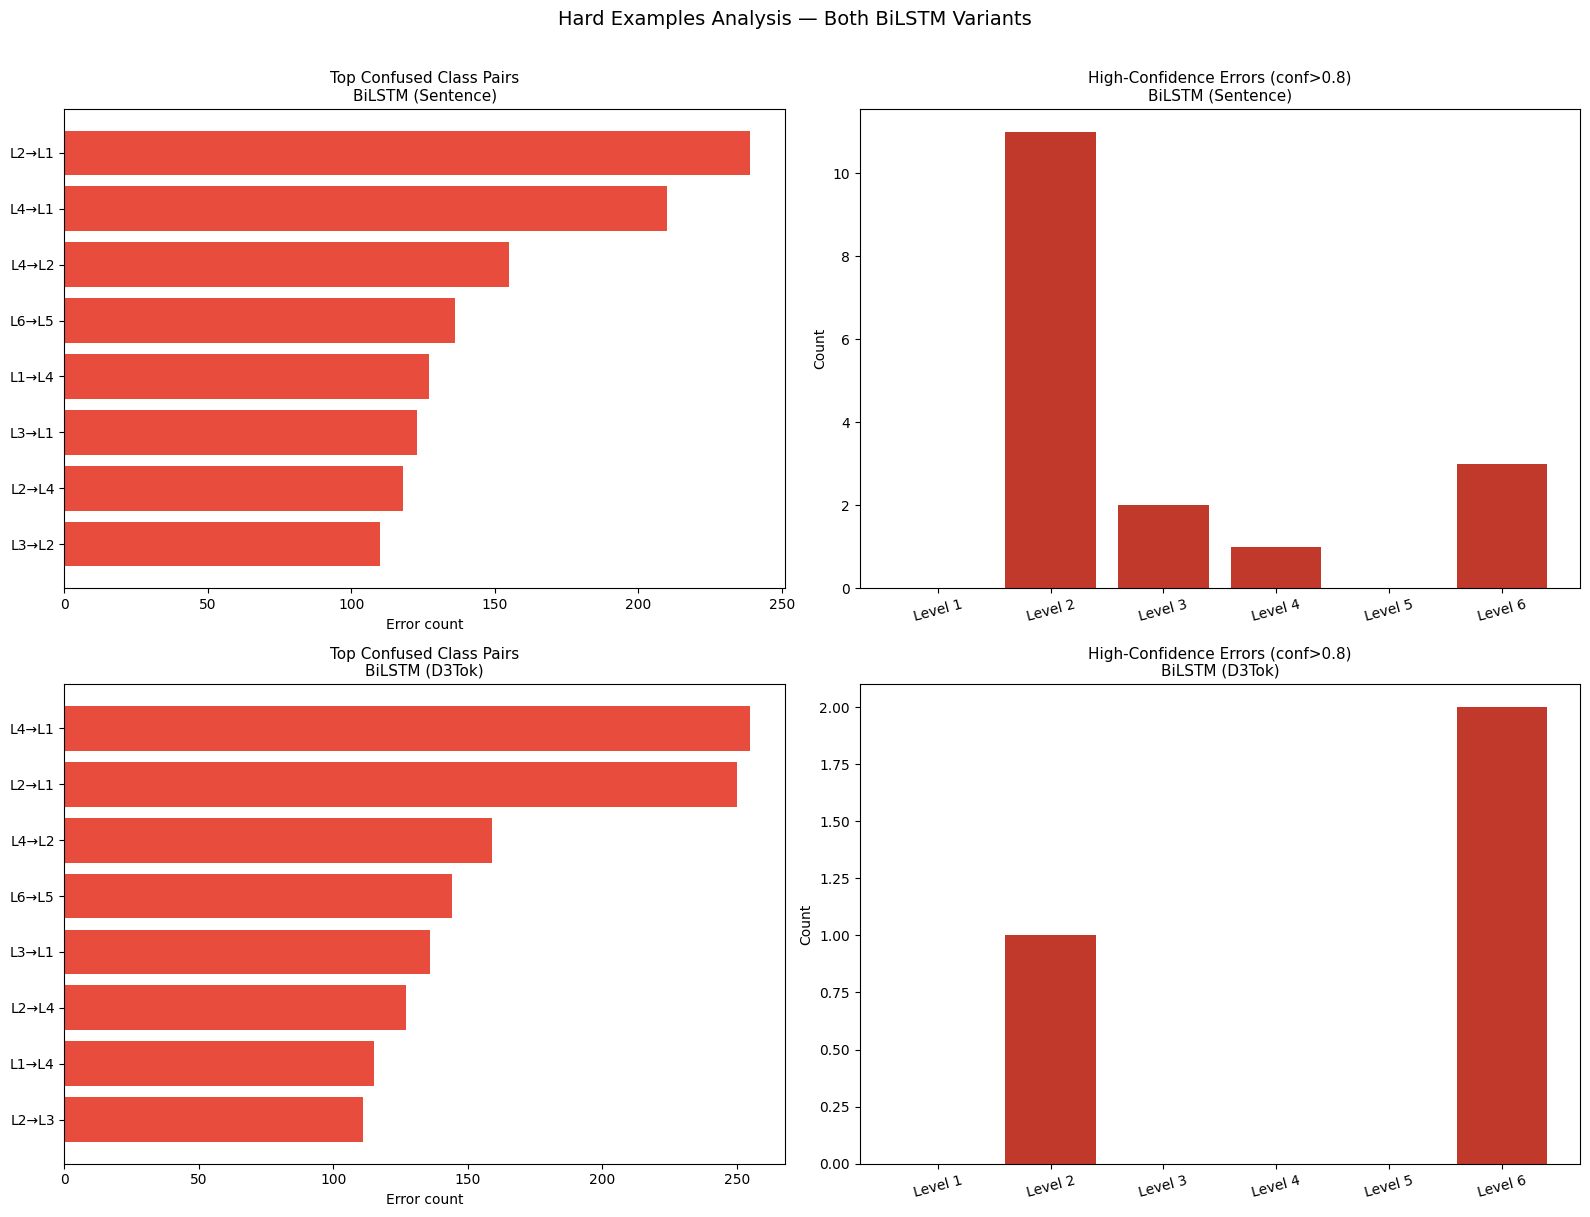

In [31]:
# ============================================================
# CELL 8 — Analysis 5: Hard examples
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row_idx, (vname, res) in enumerate(results.items()):
    df    = res["df"]
    acc   = res["acc"]
    errs  = df[~df["correct"]].copy()
    total = len(errs)

    # Top confused class pairs
    pair_counts = (errs.groupby(["true_label","pred_label"])
                   .size().reset_index(name="count")
                   .sort_values("count", ascending=False).head(8))
    pair_labels = [f"L{int(r.true_label)+1}→L{int(r.pred_label)+1}"
                   for _, r in pair_counts.iterrows()]
    axes[row_idx][0].barh(pair_labels[::-1], pair_counts["count"].values[::-1],
                           color="#e74c3c")
    axes[row_idx][0].set_xlabel("Error count")
    axes[row_idx][0].set_title(f"Top Confused Class Pairs\nBiLSTM ({vname})", fontsize=11)

    # High-confidence errors by class
    conf_thr  = 0.8
    hce       = df[(~df["correct"]) & (df["confidence"] > conf_thr)]
    hce_cnts  = hce.groupby("true_label").size().reindex(range(NUM_CLASSES), fill_value=0)
    axes[row_idx][1].bar(LEVEL_NAMES, hce_cnts.values, color="#c0392b")
    axes[row_idx][1].set_title(f"High-Confidence Errors (conf>{conf_thr})\nBiLSTM ({vname})",
                                fontsize=11)
    axes[row_idx][1].set_ylabel("Count")
    axes[row_idx][1].tick_params(axis="x", rotation=15)

    # Print top 20 hard examples
    hard = errs.sort_values("confidence", ascending=False).head(20)
    print(f"\n{'='*80}")
    print(f"TOP 20 HARD ERRORS — BiLSTM ({vname})")
    print(f"{'='*80}")
    print(f"{'#':<4} {'True':>5} {'Pred':>5} {'Conf':>6} {'Dist':>5}  {'Domain':<18}  Text")
    print("-"*80)
    for i, (_, row) in enumerate(hard.iterrows()):
        text = str(row["Sentence"])[:50] + "…" if len(str(row["Sentence"])) > 50 \
               else str(row["Sentence"])
        print(f"{i+1:<4} L{int(row['true_label'])+1}→L{int(row['pred_label'])+1}    "
              f"{row['confidence']:>5.3f}  {int(row['error_dist']):>4}   "
              f"{str(row['Domain']):<18}  {text}")

plt.suptitle("Hard Examples Analysis — Both BiLSTM Variants", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_hard_examples_both.png", dpi=150, bbox_inches="tight")
plt.show()



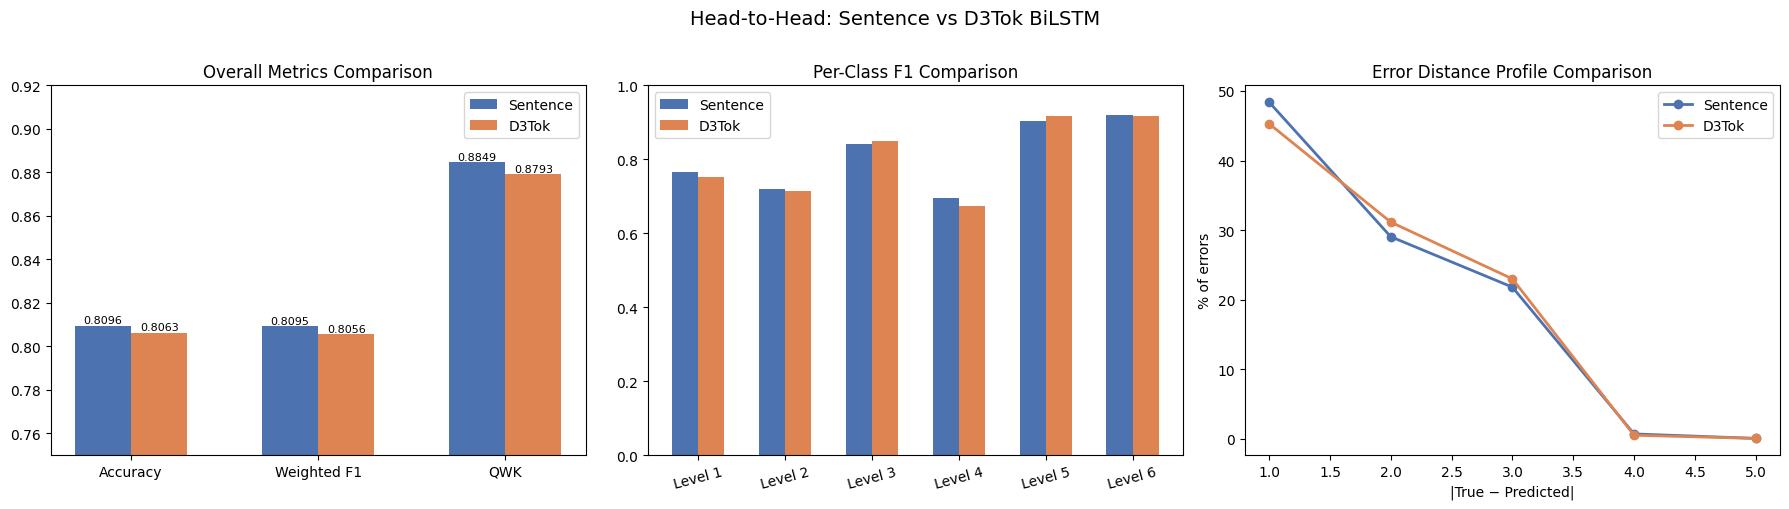

In [32]:
# ============================================================
# Head-to-head comparison
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 9a — Overall metrics comparison
metrics   = ["Accuracy", "Weighted F1", "QWK"]
sentence  = [results["Sentence"]["acc"], results["Sentence"]["f1"], results["Sentence"]["qwk"]]
d3tok     = [results["D3Tok"]["acc"],    results["D3Tok"]["f1"],    results["D3Tok"]["qwk"]]
x = np.arange(len(metrics))
w = 0.3
axes[0].bar(x - w/2, sentence, w, label="Sentence", color="#4C72B0")
axes[0].bar(x + w/2, d3tok,    w, label="D3Tok",    color="#DD8452")
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.75, 0.92)
axes[0].set_title("Overall Metrics Comparison", fontsize=12)
axes[0].legend()
for i, (s, d) in enumerate(zip(sentence, d3tok)):
    axes[0].text(i - w/2, s + 0.001, f"{s:.4f}", ha="center", fontsize=8)
    axes[0].text(i + w/2, d + 0.001, f"{d:.4f}", ha="center", fontsize=8)

# 9b — Per-class F1 comparison
f1_s = precision_recall_fscore_support(
    results["Sentence"]["labels"], results["Sentence"]["preds"],
    average=None, labels=list(range(NUM_CLASSES)))[2]
f1_d = precision_recall_fscore_support(
    results["D3Tok"]["labels"], results["D3Tok"]["preds"],
    average=None, labels=list(range(NUM_CLASSES)))[2]
x = np.arange(NUM_CLASSES)
axes[1].bar(x - w/2, f1_s, w, label="Sentence", color="#4C72B0")
axes[1].bar(x + w/2, f1_d, w, label="D3Tok",    color="#DD8452")
axes[1].set_xticks(x); axes[1].set_xticklabels(LEVEL_NAMES, rotation=15)
axes[1].set_ylim(0, 1.0)
axes[1].set_title("Per-Class F1 Comparison", fontsize=12)
axes[1].legend()

# 9c — Error distance distribution comparison
for vname, clr in zip(["Sentence","D3Tok"], ["#4C72B0","#DD8452"]):
    errs = results[vname]["df"][~results[vname]["df"]["correct"]]
    dist = errs["error_dist"].value_counts(normalize=True).sort_index() * 100
    axes[2].plot(dist.index, dist.values, "o-", color=clr, label=vname, linewidth=2)
axes[2].set_xlabel("|True − Predicted|")
axes[2].set_ylabel("% of errors")
axes[2].set_title("Error Distance Profile Comparison", fontsize=12)
axes[2].legend()

plt.suptitle("Head-to-Head: Sentence vs D3Tok BiLSTM", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/06_head_to_head.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
# ============================================================
# Summary
# ============================================================
print(f"\n{'='*60}")
print("ERROR ANALYSIS SUMMARY — Both BiLSTM Variants")
print(f"{'='*60}")
for vname, res in results.items():
    df   = res["df"]
    errs = df[~df["correct"]]
    tot  = len(errs)
    adj  = (errs["error_dist"] == 1).mean() * 100
    over = (errs["pred_label"] > errs["true_label"]).mean() * 100
    hce  = ((~df["correct"]) & (df["confidence"] > 0.8)).sum()
    print(f"\n  BiLSTM ({vname})")
    print(f"    Accuracy:              {res['acc']:.4f}")
    print(f"    Weighted F1:           {res['f1']:.4f}")
    print(f"    QWK:                   {res['qwk']:.4f}")
    print(f"    Total errors:          {tot} / {len(df)}")
    print(f"    Adjacent (dist=1):     {adj:.1f}%")
    print(f"    Non-adjacent (dist>1): {100-adj:.1f}%")
    print(f"    Over-predicted:        {over:.1f}%")
    print(f"    Under-predicted:       {100-over:.1f}%")
    print(f"    High-conf errors>0.8:  {hce}")

print(f"\nSaved {len(os.listdir(OUT_DIR))} files to {OUT_DIR}/")

# Download
os.chdir("/kaggle/working")
shutil.make_archive("error_analysis_both", "zip", OUT_DIR)
display(FileLink("error_analysis_both.zip"))


ERROR ANALYSIS SUMMARY — Both BiLSTM Variants

  BiLSTM (Sentence)
    Accuracy:              0.8096
    Weighted F1:           0.8095
    QWK:                   0.8849
    Total errors:          1711 / 8984
    Adjacent (dist=1):     48.4%
    Non-adjacent (dist>1): 51.6%
    Over-predicted:        33.8%
    Under-predicted:       66.2%
    High-conf errors>0.8:  17

  BiLSTM (D3Tok)
    Accuracy:              0.8063
    Weighted F1:           0.8056
    QWK:                   0.8793
    Total errors:          1740 / 8984
    Adjacent (dist=1):     45.3%
    Non-adjacent (dist>1): 54.7%
    Over-predicted:        32.9%
    Under-predicted:       67.1%
    High-conf errors>0.8:  3

Saved 6 files to /kaggle/working/error_analysis_both/


/kaggle/working/error_analysis_both.zip